In [2]:
import random as random
import numpy as np

# Sugar

In [3]:
def linearDiffusion(point, plane):
    xpoint, ypoint = point
    xplane, yplane = plane

    if xpoint < 0 or ypoint < 0:
        return "Point not within range"

    if xplane < 0 or yplane < 0:
        return "Plane not within range"

    if xpoint > xplane or ypoint > yplane:
        return "Point not within plane"

    return xpoint / xplane
    # The y coordinates do not matter for this calculation,
    # but they are defined for code organization.

In [4]:
#linear circular diffusion with the circleCenter being the highest concentration, and everypoint next to the
import math

def circularDiffusion(origin, point, time, diffusion_coefficient, numMolec):
    x_origin, y_origin = origin
    x_point, y_point = point

    if time <= 0:
        return "Time must be positive"

    # Calculate the distance from the origin to the point
    distance = math.sqrt((x_point - x_origin) ** 2 + (y_point - y_origin) ** 2)

    # Calculate the concentration using a Gaussian distribution model
    concentration = numMolec*(1 / (4 * math.pi * diffusion_coefficient * time)) * math.exp(-distance**2 / (4 * diffusion_coefficient * time))

    return concentration

# Example usage:
origin = (0, 0)
point = (1, 1)
time = 2
diffusion_coefficient = 1  # This would depend on the specific substance and medium

concentration = circularDiffusion(origin, point, time, diffusion_coefficient, 100)
print(f"The concentration at point {point} after {time} time units is {concentration:.4f}")

The concentration at point (1, 1) after 2 time units is 3.0987


In [5]:
def distanceDiffusion(point, axis,i):
  D = 10000
  return (60000000 / np.sqrt(4*np.pi * i * D +0.0001) * (-(point-axis)**2 / (4*i*D+0.0001)))

In [6]:
def goal_x(point, x_axis):
  return 1/abs(x_axis-point[0])

In [7]:
def goal_point(point, goal) :
  x_goal, y_goal = goal
  x_point, y_point = point
  distance = (x_point - x_goal) ** 2 + (y_point - y_goal) ** 2

  return 1/distance

# Bacteria


1 unit by 1 unit

15 body lengths per second

with no stimuli, 1-10 seconds between tumbles

time scale: 10s of milliseconds

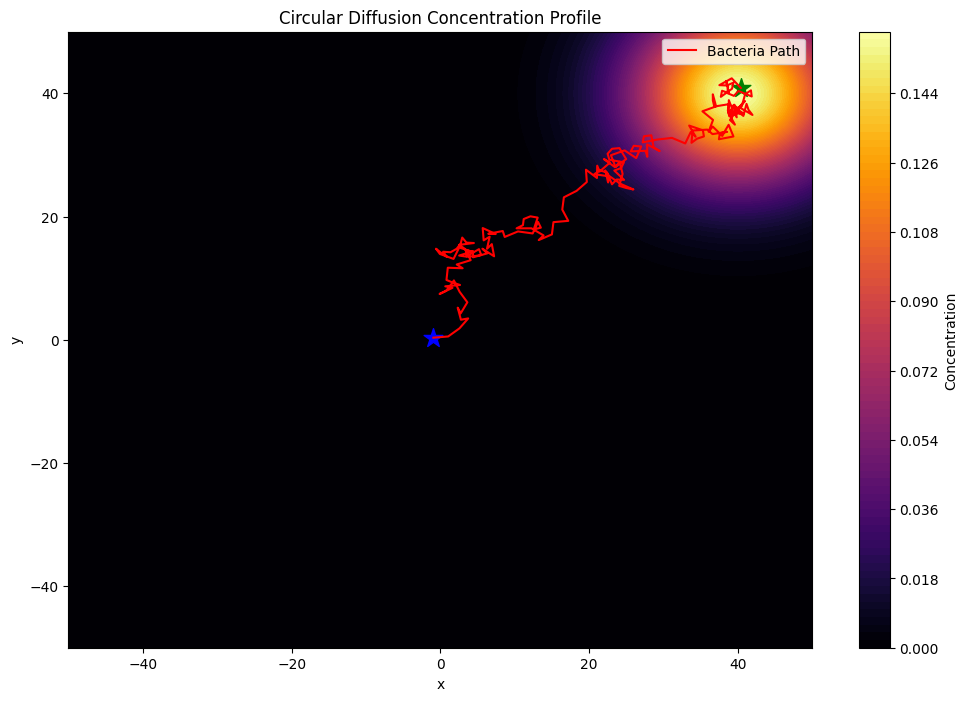

In [8]:

#linear circular diffusion with the circleCenter being the highest concentration, and everypoint next to the
import numpy as np
import random as r
import math
import matplotlib.pyplot as plt



def circularDiffusion(origin, point, time, diffusion_coefficient, numMolec):
    x_origin, y_origin = origin
    x_point, y_point = point

    if time <= 0:
        return "Time must be positive"

    # Calculate the distance from the origin to the point
    distance = math.sqrt((x_point - x_origin) ** 2 + (y_point - y_origin) ** 2)

    # Calculate the concentration using a Gaussian distribution model
    concentration = numMolec*(1 / (4 * math.pi * diffusion_coefficient * time)) * math.exp(-distance**2 / (4 * diffusion_coefficient * time))

    return concentration

def timeWalk(Cprev,C,time):
  if Cprev>C:
    time = 0
  elif C>=Cprev:
    time = 1
  return time

def randAngle():
  return random.uniform(0,2*np.pi)




#bacteria movement
C = 1
Cprev = 1
spreadness = 50
diffusion_coefficient = 1
numMolec = 100
goal = (40,40)
steps = 200
time = 0

bactPos = [0,0]
bactAngle = 0

posesX = np.array(np.zeros(steps))
posesY = np.array(np.zeros(steps))






for i in range(steps):
  Cprev = circularDiffusion(goal, bactPos, 10, diffusion_coefficient, numMolec)
  bactAngle = randAngle()
  bactPos[0] += np.cos(bactAngle)
  bactPos[1] += np.sin(bactAngle)
  C = circularDiffusion(goal, bactPos, 10, diffusion_coefficient, numMolec)
  time = timeWalk(Cprev,C,time)
  bactPos[0] += (np.cos(bactAngle)*time)
  bactPos[1] += (np.sin(bactAngle)*time)
  posesX[i] = bactPos[0]
  posesY[i] = bactPos[1]

# Create a grid for contour plot
x = np.linspace(-50, 50, 500)
y = np.linspace(-50, 50, 500)
meshx, meshy = np.meshgrid(x, y)

# Calculate concentrations on the grid
concentrations_circular = np.zeros((len(x), len(y)))
for i in range(len(x)):
    for j in range(len(y)):
        concentrations_circular[i, j] = circularDiffusion(goal, (x[i], y[j]), spreadness, diffusion_coefficient, numMolec)

  # Plot the results
plt.figure(figsize=(12, 8))
plt.contourf(meshx, meshy, concentrations_circular, levels=100, cmap='inferno')
plt.colorbar(label='Concentration')

# Plot goal
#plt.scatter(goal[0], goal[1], marker='*', color='b', s=900, label='Goal')

# Plot bacteria path
plt.plot(posesX, posesY, 'r-', label='Bacteria Path')


plt.xlabel('x')
plt.ylabel('y')
plt.title('Circular Diffusion Concentration Profile')
plt.legend()
plt.scatter(posesX[-1], posesY[-1], marker='*', color='g', s=200, label='Final Position')
plt.scatter(posesX[0], posesY[0], marker='*', color='b', s=200, label='Start Position')
plt.show()


/bin/bash: line 1: import: command not found


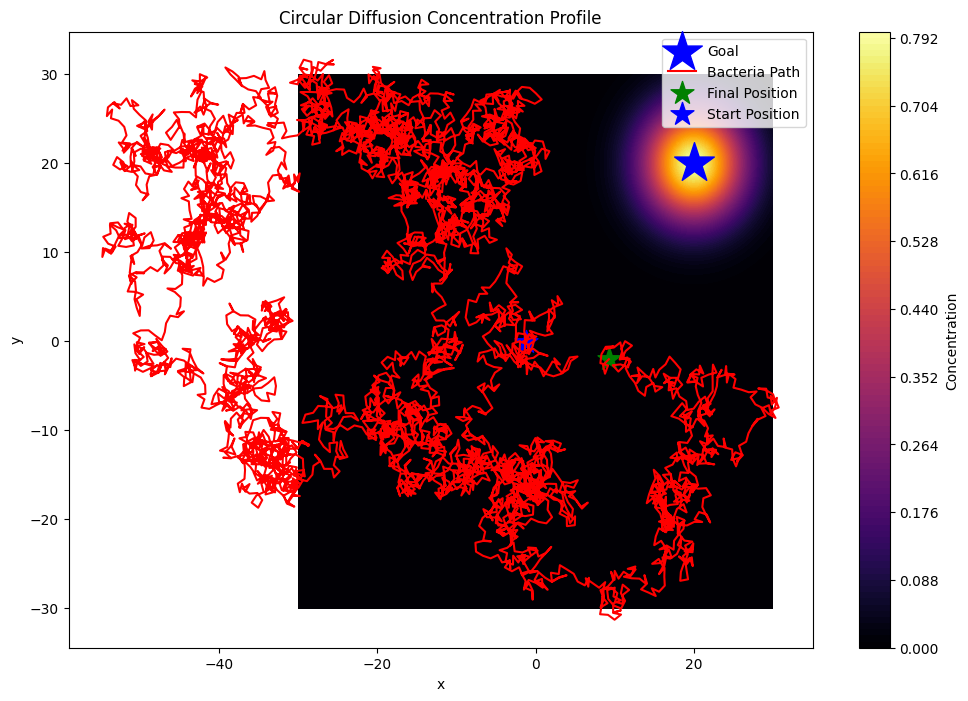

In [9]:
!import numpy as np
import matplotlib.pyplot as plt
import math

# Circular diffusion function
def circularDiffusion(origin, point, time, diffusion_coefficient, numMolec):
    x_origin, y_origin = origin
    x_point, y_point = point

    if time <= 0:
        return "Time must be positive"

    # Calculate the distance from the origin to the point
    distance = np.sqrt((x_point - x_origin) ** 2 + (y_point - y_origin) ** 2)

    # Calculate the concentration using a Gaussian distribution model
    concentration = numMolec * (1 / (4 * np.pi * diffusion_coefficient * time)) * \
                    np.exp(-distance**2 / (4 * diffusion_coefficient * time))

    return concentration

# Function to determine time based on concentration
def timeWalk(Cprev, C, time):
    if Cprev > C:
        time *= 0.25
    else:
        time *= 1
    return time

# Simulation parameters
num_steps = 5000
diffusion_coefficient = 1
numMolec = 100
bactPos = np.array([0.0, 0.0])
goal = np.array([20.0, 20.0])
spreadness = 10
time = 1.0

# Arrays to store the positions
posesX = np.zeros(num_steps)
posesY = np.zeros(num_steps)

# Run simulation
for i in range(num_steps):
    Cprev = circularDiffusion(goal, bactPos, 10, diffusion_coefficient, numMolec)

    # Random angle for the bacteria movement
    bactAngle = np.random.uniform(0, 2 * np.pi)

    # Move bacteria
    bactPos[0] += np.cos(bactAngle)
    bactPos[1] += np.sin(bactAngle)

    # Compute new concentration and adjust time
    C = circularDiffusion(goal, bactPos, 10, diffusion_coefficient, numMolec)
    time = timeWalk(Cprev, C, time)

    # Move bacteria with updated time
    bactPos[0] += np.cos(bactAngle) * time
    bactPos[1] += np.sin(bactAngle) * time

    # Store positions
    posesX[i] = bactPos[0]
    posesY[i] = bactPos[1]

# Create a grid for contour plot
x = np.linspace(-30, 30, 600)
y = np.linspace(-30, 30, 600)
meshx, meshy = np.meshgrid(x, y)

# Calculate concentrations on the grid
concentrations_circular = np.zeros((len(x), len(y)))
for i in range(len(x)):
    for j in range(len(y)):
        concentrations_circular[i, j] = circularDiffusion(goal, (x[i], y[j]), spreadness, diffusion_coefficient, numMolec)

# Plot the results
plt.figure(figsize=(12, 8))
plt.contourf(meshx, meshy, concentrations_circular, levels=100, cmap='inferno')
plt.colorbar(label='Concentration')

# Plot goal
plt.scatter(goal[0], goal[1], marker='*', color='b', s=900, label='Goal')

# Plot bacteria path
plt.plot(posesX, posesY, 'r-', label='Bacteria Path')
plt.scatter(posesX[-1], posesY[-1], marker='*', color='g', s=300, label='Final Position')
plt.scatter(posesX[0], posesY[0], marker='*', color='b', s=300, label='Start Position')

plt.xlabel('x')
plt.ylabel('y')
plt.title('Circular Diffusion Concentration Profile')
plt.legend()
plt.show()
